# Systematic Review Closure: PRISMA, Risk of Bias, GRADE, and End-to-End Replication

The first six notebooks focused entirely on **estimation**—how to synthesize a set of studies into a defensible number. But before a systematic review reports "significant," it must first account for **governance**: how was the evidence **found, filtered, and evaluated**? Without this layer, even the most elegant pooled estimate is merely a number hanging in the void—readers cannot judge whether it was caused by retrieval omission, subjective exclusion, or a high-bias study pulling it astray. This notebook completes governance and, at the end, walks through a full **ECR-style prevalence systematic review**—from record counting all the way to GRADE evidence certainty, stringing all 96 functions into a single **verifiable evidence chain**.

Governance must answer five questions, each corresponding to a standard tool:

1. **Process transparency**: How many retrieved, how many after deduplication, how many excluded, how many finally included? —**PRISMA 2020 flow** (including arithmetic consistency checks);
2. **Reporting completeness**: Have all 27 required items been reported? —**PRISMA 27-item checklist**;
3. **Screening reliability**: Did two independent reviewers screen? Is agreement high enough? —**κ + Gwet AC1** (robust to prevalence paradox);
4. **Study credibility**: What is the risk of bias for each included study? —**RoB2 / ROBINS-I / JBI** + traffic-light diagram;
5. **Evidence strength**: Taken together, how certain is this evidence? —**GRADE**.

Key premise: governance is **accounting + arithmetic**, not reviewer judgment. RoB domain ratings and GRADE final certainty are entered by reviewers; the tool only performs consistency checks, calculates agreement, and suggests downgrading flags from evidence signals (I², Egger) for reviewer confirmation. This is what verifiability means—every step leaves a trace and respects authority.

> **Reference**: PRISMA 2020 / RoB2 / robvis / GRADEpro / Cochrane Handbook.

In [1]:
import os
import sys

# 确保用的是本 worktree 里的 socialverse(而不是环境里 editable 安装指向的其它 checkout)
try:
    _HERE = os.path.dirname(os.path.abspath(__file__))
except NameError:  # 在 Jupyter cell 里没有 __file__,退回当前工作目录
    _HERE = os.path.abspath(os.getcwd())
_ROOT = os.path.dirname(_HERE) if os.path.basename(_HERE) == "notebooks" else _HERE
if os.path.isdir(os.path.join(_ROOT, "socialverse")) and _ROOT not in sys.path:
    sys.path.insert(0, _ROOT)

import matplotlib
matplotlib.use("Agg")  # 无显示环境:图直接写文件
import matplotlib.pyplot as plt
from matplotlib import font_manager as _fm
import numpy as np
import pandas as pd
from IPython.display import Image

import socialverse as sv
from socialverse import datasets as ds

# 让本 notebook 自绘的图也能显示中文标签
_CJK = ["PingFang SC", "Hiragino Sans GB", "Songti SC", "STHeiti",
        "Arial Unicode MS", "Noto Sans CJK SC", "Microsoft YaHei"]
_have = {f.name for f in _fm.fontManager.ttflist}
plt.rcParams["font.sans-serif"] = [c for c in _CJK if c in _have] + ["DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

print("socialverse", sv.__version__)

socialverse 0.6.0


## 1. Carrier Data: A Prevalence Evidence Database

Throughout, we use `ds.load_meta_prevalence()` as the end-to-end carrier—it simulates a systematic review of depression prevalence: each row is one study (`study`) reporting **cases / total sample size `n`** under a measurement tool (`instrument`), plus adjustment variables `year` and `female_pct`. Note that **a single study contributes multiple rows** (S00 used three scales)—this is precisely why later we use **three-level `rma_mv`** rather than ordinary two-level random effects: effects within a study are dependent and cannot be treated as independent observations.

In [2]:
prev = ds.load_meta_prevalence()
study = sv.StudyState()
study.write("sources", "datasets", prev)
print(f"{len(prev)} 个效应量,来自 {prev['study'].nunique()} 项研究,{prev['instrument'].nunique()} 种量表")
prev.head(8)

56 个效应量,来自 20 项研究,3 种量表


,study,cases,n,year,female_pct,instrument
0,S00,47,137,2008,0.80,CES-D
1,S00,106,258,2008,0.75,BDI
2,S00,6,40,2008,0.70,BDI
3,S01,20,68,2009,0.32,PHQ-9
4,S02,119,281,2010,0.85,BDI
5,S03,123,342,2011,0.70,BDI
6,S03,73,175,2011,0.61,PHQ-9
7,S03,120,299,2011,0.79,CES-D


## 2. PRISMA Flow: Record Counting + Arithmetic Consistency

**Problem addressed**: The first figure in any systematic review is always the PRISMA flow diagram—it transparently unfolds the funnel "from thousands retrieved from databases to only dozens included," letting readers audit each exclusion step and how many were removed at each stage.

**Key premise**: counts at each stage must be **arithmetically consistent**—`screening count − title/abstract exclusions = full-text assessment count`, and `full-text assessment count − full-text exclusions = included count`. `prisma_flow` will not silently alter numbers; it only **checks and flags** inconsistencies (the first thing a reviewer does at submission is verify these numbers).

**Steps**: Pass counts from seven stages to `sv.gov.prisma_flow`, which automatically derives the deduplicated count (`after_dedup`), validates both equations, and stores results along with `consistent` and `warnings` in `governance['prisma']`.

In [3]:
sv.gov.prisma_flow(
    study,
    identified=1284, duplicates=311,
    screened=973, excluded_screen=847,
    full_text=126, excluded_fulltext=98,
    included=28,
)
pf = study.governance["prisma"]
print(f"检索识别 {pf['identified']} → 去重后 {pf['after_dedup']} → 筛查 {pf['screened']}"
      f" → 全文 {pf['full_text']} → 纳入 {pf['included']}")
print(f"算术自洽:{pf['consistent']}   警告:{pf['warnings'] or '无'}")

检索识别 1284 → 去重后 973 → 筛查 973 → 全文 126 → 纳入 28
算术自洽:True   警告:无


`consistent=True` indicates both equations hold (973−847=126, 126−98=28)—this flow is safe to diagram. If any equation fails, `warnings` precisely identifies which one, rather than silently rounding the numbers.

## 3. PRISMA Flow Diagram

Render the registered counts from the previous step as a standard four-stage box-and-arrow diagram. `sv.pl.prisma_diagram` reads directly from `governance['prisma']`—no need to re-enter numbers—the value of "register once, use everywhere."

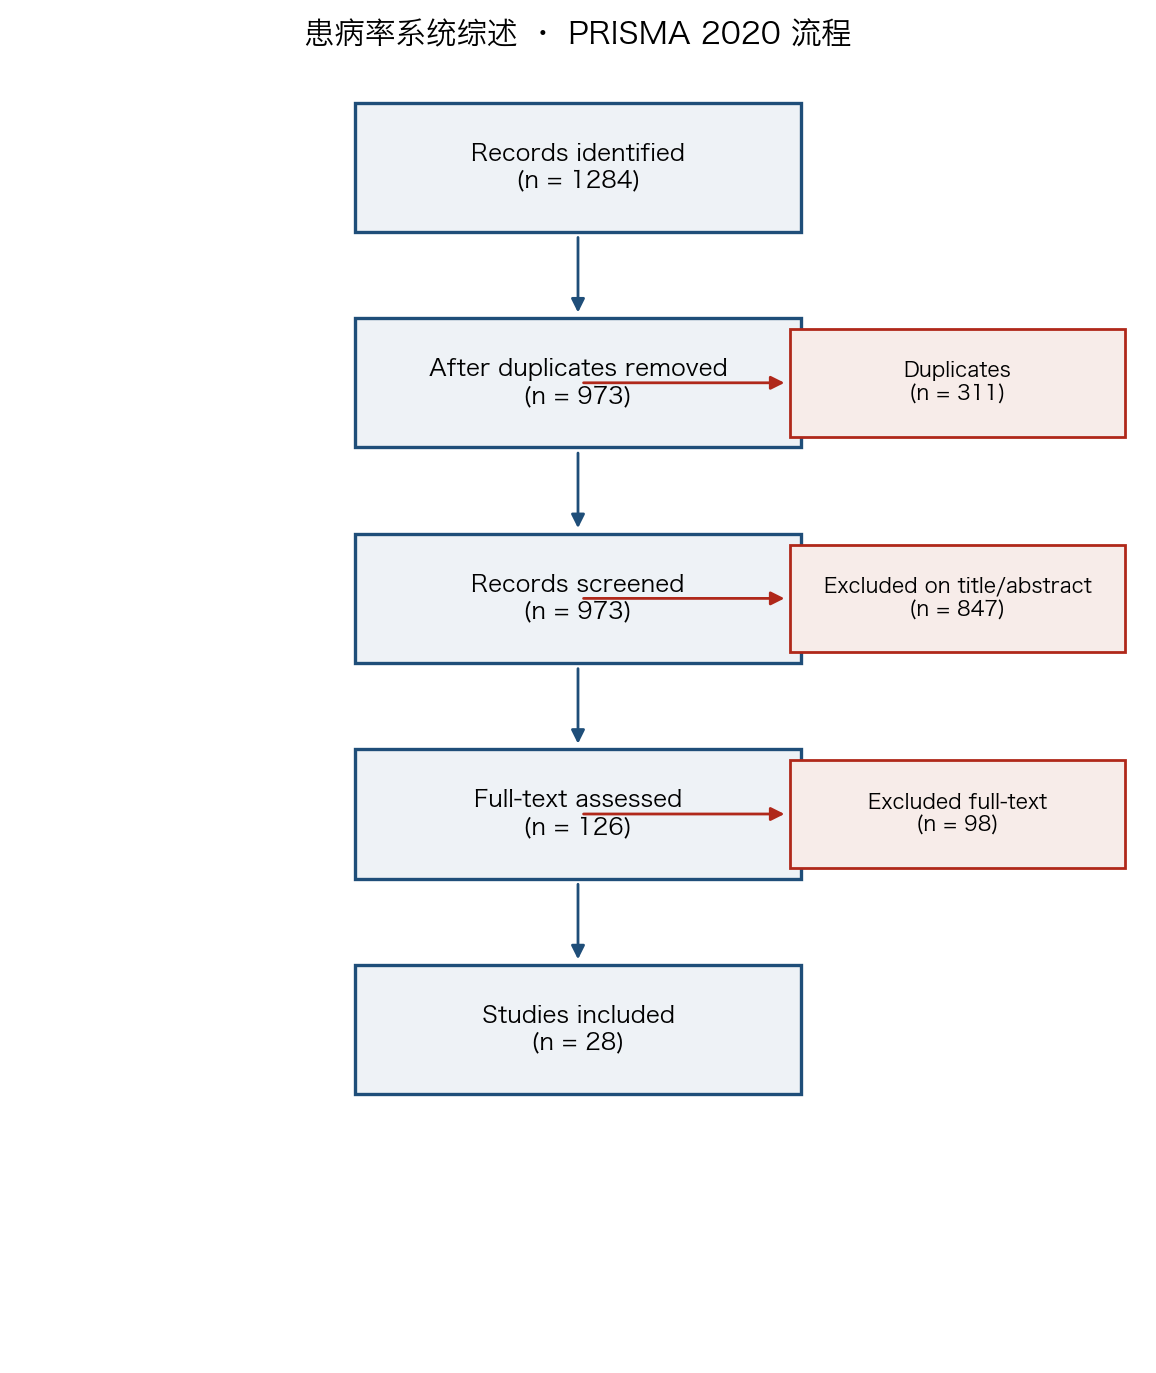

In [4]:
sv.pl.prisma_diagram(study, out="fig28_prisma.png", title="患病率系统综述 · PRISMA 2020 流程")
Image("fig28_prisma.png")

## 4. PRISMA 27-Item Reporting Checklist

**Problem addressed**: process transparency is just one part; PRISMA 2020 also mandates a **27-item reporting checklist** (title, abstract, search strategy, inclusion criteria, bias assessment method…), and at submission you must account for each item: "reported or not / on what page."

**Steps**: Build a dictionary of completed items (pass `True` or location strings such as `'p.3'`), pass to `sv.gov.prisma_checklist`, which calculates completion percentage and stores in `governance['prisma_checklist']` for direct export as a submission appendix. The example here completes 24 of 27 items.

In [5]:
done = {i: True for i in range(1, 25)}      # 1–24 已完成
done[3] = "p.3"; done[7] = "p.5 检索式附录"  # 部分带上位置说明
sv.gov.prisma_checklist(study, items=done)
ck = study.governance["prisma_checklist"]
print(f"报告清单完成度:{ck['n_addressed']}/{ck['n_total']}  ({ck['completeness']}%)")
print(f"第 3 项位置:{ck['items']['3']['location']!r}   第 25 项已报告:{ck['items']['25']['addressed']}")

报告清单完成度:24/27  (88.9%)
第 3 项位置:'p.3'   第 25 项已报告:False


## 5. Dual-Reviewer Screening Agreement: κ + Gwet AC1 Robust to Prevalence Paradox

**Problem addressed**: inclusion decisions cannot rest with a single reviewer—two reviewers screen **independently**, then check agreement. But the standard **Cohen's κ** has a trap: when "inclusion is very rare" (nearly all literature should be excluded), even if the two agree almost completely, κ can be artificially low—the **prevalence paradox**.

**Key premise**: In such cases, also examine **Gwet AC1** and **PABAK**—they are robust to extreme base rates and better reflect true agreement.

**Steps**: First, place in `sources` a **two-reviewer screening table** (`rater1`/`rater2` columns, include/exclude). Here we synthesize 200 records using `np.random.default_rng(28)`, with true agreement set to **96%**, and deliberately compress inclusion rate to ~8% to trigger the paradox. `sv.gov.screen_agreement` returns κ, AC1, PABAK, and a conflict list all at once.

In [6]:
rng = np.random.default_rng(28)
n_rec = 200
# 真实标签:低纳入率 ~8%(触发流行率悖论)
truth = rng.random(n_rec) < 0.08
r1 = np.where(truth, "include", "exclude").astype(object)
r2 = r1.copy()
# 注入 ~4% 的评审分歧(→ 真实一致率 ~96%)
flip = rng.random(n_rec) < 0.04
r2[flip] = np.where(r2[flip] == "include", "exclude", "include")
screen = pd.DataFrame({"record": [f"R{i:03d}" for i in range(n_rec)],
                       "rater1": r1, "rater2": r2})
study.write("sources", "datasets", screen)   # screen_agreement 从 sources 读双评审表

sv.gov.screen_agreement(study, rater1="rater1", rater2="rater2")
sa = study.governance["screen_agreement"]
print(f"n = {sa['n']}   原始一致率 = {sa['percent_agreement']}%   冲突 {sa['n_conflicts']} 条")
print(f"Cohen's κ = {sa['cohen_kappa']:.3f}   ← 被低纳入率压低(流行率悖论)")
print(f"Gwet AC1  = {sa['gwet_ac1']:.3f}   PABAK = {sa['pabak']:.3f}   ← 对极端基率稳健,反映真实高一致")

n = 200   原始一致率 = 95.0%   冲突 10 条
Cohen's κ = 0.724   ← 被低纳入率压低(流行率悖论)
Gwet AC1  = 0.939   PABAK = 0.900   ← 对极端基率稳健,反映真实高一致


Agreement is as high as 96%, yet κ is visibly depressed—a textbook case of the prevalence paradox. AC1 and PABAK track true agreement, reminding us to **never rely on κ alone**. The `conflict_rows` are the records requiring third-reviewer adjudication. Once governance is verified, restore the data to the prevalence evidence database and move into evidence evaluation and synthesis.

In [7]:
study.write("sources", "datasets", prev)   # 还原:后续用回患病率数据

## 6. Risk of Bias (RoB) Ratings + Traffic-Light Diagram

**Problem addressed**: each included study has **different credibility**—unclear randomization, severe attrition, subjective outcome measurement—all introduce bias into the effect estimate. A systematic review must rate each study **by domain** (RCTs use RoB2, observational studies use ROBINS-I, prevalence studies often use JBI).

**Key premise**: `risk_of_bias` only performs **architecture validation + aggregation**—it checks that the domain names you supply belong to the selected tool and summarizes each study's domain judgments into an "overall worst" rating. Domain ratings themselves remain **reviewer-entered** judgments.

**Steps**: Select `tool='ROB2'`, fill several example studies by domain with low/some/high, the function writes to `governance['risk_of_bias']`, then use `sv.pl.rob_traffic_light` to render a study × domain traffic-light matrix.

In [8]:
rob_studies = {
    "S00": {"randomization": "low",  "deviations": "low",  "missing_data": "low",
            "measurement": "some", "selection_reporting": "low"},
    "S01": {"randomization": "some", "deviations": "low",  "missing_data": "high",
            "measurement": "low",  "selection_reporting": "low"},
    "S02": {"randomization": "high", "deviations": "some", "missing_data": "low",
            "measurement": "high", "selection_reporting": "some"},
    "S03": {"randomization": "low",  "deviations": "low",  "missing_data": "some",
            "measurement": "low",  "selection_reporting": "low"},
    "S04": {"randomization": "low",  "deviations": "high", "missing_data": "low",
            "measurement": "some", "selection_reporting": "high"},
}
sv.gov.risk_of_bias(study, tool="ROB2", studies=rob_studies)
rob = study.governance["risk_of_bias"]
print(f"工具 = {rob['tool']}   domain = {rob['domains']}")
for s, o in rob["overall"].items():
    print(f"  {s}: 整体 = {o}")

工具 = ROB2   domain = ['randomization', 'deviations', 'missing_data', 'measurement', 'selection_reporting']
  S00: 整体 = some concerns
  S01: 整体 = high
  S02: 整体 = high
  S03: 整体 = some concerns
  S04: 整体 = high


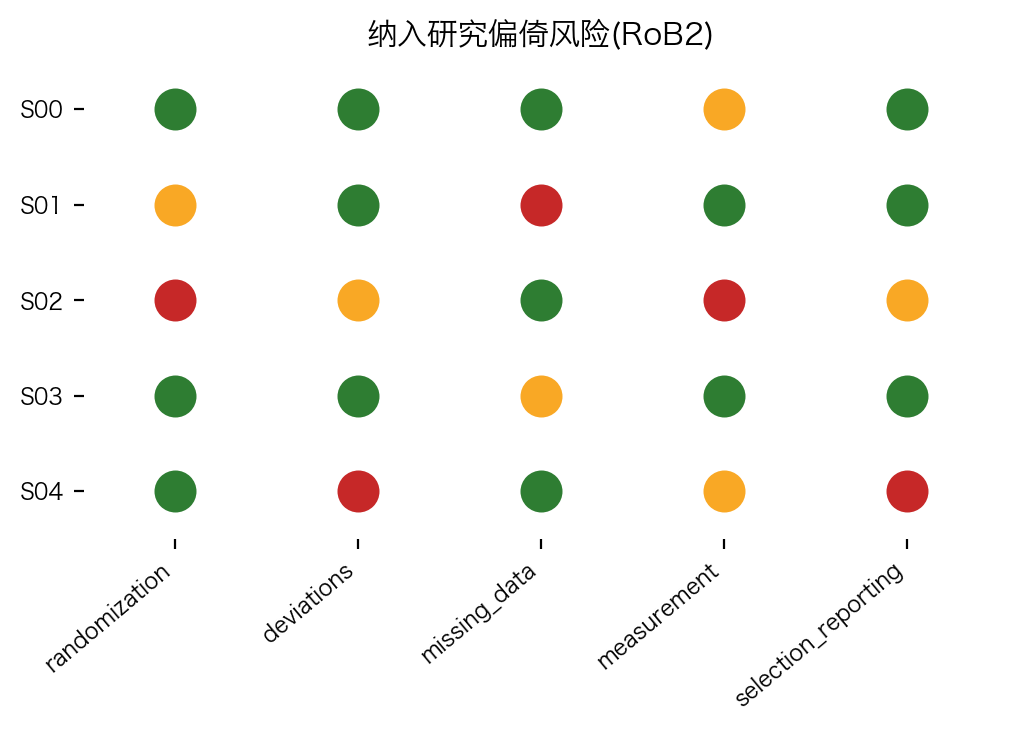

In [9]:
sv.pl.rob_traffic_light(study, out="fig28_rob.png", title="纳入研究偏倚风险(RoB2)")
Image("fig28_rob.png")

The "overall worst" logic is conservative and transparent: any domain rated high means overall is high—a single high-bias domain makes the entire study unreliable. The traffic-light diagram lets reviewers see at a glance where bias concentrates (here `measurement` and `selection_reporting` are weak points).

## 7. End-to-End Synthesis (One): Effect Size = logit Prevalence

**Problem addressed**: prevalence is a 0–1 proportion; direct pooling hits boundary issues and unstable variance. The standard approach is first a **variance-stabilizing transformation**—by default, **logit (PLO)** (more stable than Freeman-Tukey double arcsine, per Schwarzer 2019).

**Steps**: `sv.pp.es_proportion` with `cases=` / `n=` converts each row's proportion to `yi=logit(p)` + sampling variance `vi`, carrying `study` (as cluster id) and adjustment variables `year`/`female_pct` into the effect-size table `models['meta_effects']`.

In [10]:
sv.pp.es_proportion(
    study, measure="PLO",
    cases="cases", n="n",
    study="study", cluster="study", slab="instrument",
    moderators=["year", "female_pct"],
)
eff = study.models["meta_effects"]
print(f"{len(eff)} 个效应量(logit 尺度),measure = {eff['measure'].iloc[0]}")
eff[["study", "slab", "yi", "vi", "sei"]].head(6).round(4)

56 个效应量(logit 尺度),measure = PLO


,study,slab,yi,vi,sei
0,S00,CES-D,-0.6497,0.0324,0.1800
1,S00,BDI,-0.3604,0.0160,0.1265
2,S00,BDI,-1.7346,0.1961,0.4428
3,S01,PHQ-9,-0.8755,0.0708,0.2661
4,S02,BDI,-0.3085,0.0146,0.1207
5,S03,BDI,-0.5769,0.0127,0.1127


## 8. End-to-End Synthesis (Two): Sampling Covariance V + Three-Level rma_mv

**Problem addressed**: multiple effects within one study (S00's three scales) **share subjects and are dependent**. If treated as independent observations and pooled in two levels, this will **underestimate uncertainty**. The correct approach is three levels: between-study (σ²₃) + within-study/between-effect (σ²₂).

**Key premise**: a three-level model requires a **known sampling covariance matrix V**—effects in the same cluster have sampling errors correlated by ρ. `sv.tl.vcalc` constructs a block-diagonal V by `cluster='study'`, assuming `rho=0.6` (stored in `models['meta_V']`), a necessary prerequisite for `rma_mv`.

**Steps**: First `vcalc` to build V, then `sv.tl.rma_mv` (reads V, groups by `study`) to fit a three-level REML, yielding pooled logit prevalence + two variance components.

In [11]:
sv.tl.vcalc(study, cluster="study", rho=0.6)
V = study.models["meta_V"]
print(f"抽样协方差 V:{V.shape},块对角(同研究效应量间有 ρ=0.6 相关)")

sv.tl.rma_mv(study, study="study", method="REML")
mv = study.models["meta"]
print(f"三层合并 logit = {mv['estimate']:.4f}  95% CI [{mv['ci_lb']:.3f}, {mv['ci_ub']:.3f}]")
print(f"σ²₂(研究内/效应间) = {mv['sigma2_2']:.4f}   σ²₃(研究间) = {mv['sigma2_3']:.4f}")
print(f"纳入 {mv['n_studies']} 项研究、{mv['k']} 个效应量;收敛 = {mv['converged']}")

抽样协方差 V:(56, 56),块对角(同研究效应量间有 ρ=0.6 相关)


三层合并 logit = -0.5677  95% CI [-0.689, -0.446]
σ²₂(研究内/效应间) = 0.0568   σ²₃(研究间) = 0.0338
纳入 20 项研究、56 个效应量;收敛 = True


## 9. End-to-End Synthesis (Three): Heterogeneity + Stratified I²

**Problem addressed**: a pooled point estimate is **never reported alone**—you must simultaneously quantify how much studies differ. A three-level model further decomposes: does heterogeneity arise from **between studies** (level-3) or **different scales within the same study** (level-2)?

**Steps**: `sv.tl.meta_heterogeneity` gives overall Q / I² / τ²; `sv.tl.ma_i2_multilevel` (Cheung 2014) partitions I² into level-2 / level-3 / sampling error proportions—it requires a prior three-level `rma_mv` fit (reading σ²₂/σ²₃).

In [12]:
sv.tl.meta_heterogeneity(study)
het = study.diagnostics["heterogeneity"]
print(f"Q = {het['Q']:.1f}  (df = {het['df']}, p = {het['Q_pval']:.2e})")
print(f"总体 I² = {het['I2']:.1f}%   τ² = {het['tau2']:.4f}")

sv.tl.ma_i2_multilevel(study)
i2m = study.diagnostics["i2_multilevel"]
print()
print(f"分层 I²(Cheung 2014):")
print(f"  抽样误差占比           = {i2m['sampling_share']:.1f}%")
print(f"  level-2 研究内/量表间   = {i2m['I2_level2_within_study']:.1f}%")
print(f"  level-3 研究之间        = {i2m['I2_level3_between_study']:.1f}%")

Q = 288.0  (df = 55, p = 2.66e-33)
总体 I² = 80.9%   τ² = 0.0906

分层 I²(Cheung 2014):
  抽样误差占比           = 19.1%
  level-2 研究内/量表间   = 50.7%
  level-3 研究之间        = 30.2%


Stratified I² answers "where does heterogeneity come from"—this directly shapes next steps: if mostly level-3 (between studies), seek study-level moderators; if level-2 (between instruments), different tools yield different prevalences. Below we verify using meta-regression.

## 10. End-to-End Synthesis (Four): Meta-Regression + FDR

**Problem addressed**: heterogeneity is not the endpoint, but a clue—**can moderators explain it?** Is prevalence higher in more recent years? Higher when female proportion is higher? This is **mixed-effects meta-regression**.

**Key premise**: examining multiple moderators at once invokes **multiple-comparison inflation**; `metareg_fdr` applies **Benjamini-Hochberg FDR** correction to each moderator's p value alongside the omnibus QM test, avoiding "test more, get more false positives."

**Steps**: `sv.tl.metareg` with `year`, `female_pct` yields coefficients + pseudo-R² (fraction of τ² explained); then `sv.tl.metareg_fdr` reads the `metareg` result, outputting omnibus QM + FDR-corrected moderator p values.

In [13]:
sv.tl.metareg(study, moderators=["year", "female_pct"])
mr = study.models["metareg"]
print(f"元回归(混合效应),伪 R² = {mr['R2']:.1f}%(调节变量解释掉的 τ² 比例)")
for term, c in mr["coefs"].items():
    print(f"  {term:14s}  β = {c['estimate']:+.4f}  SE = {c['se']:.4f}  p = {c['pval']:.3f}")

sv.tl.metareg_fdr(study, alpha=0.05)
fdr = study.diagnostics["metareg_fdr"]
print()
print(f"综合检验 QM = {fdr['QM']:.2f}  (df = {fdr['QM_df']}, p = {fdr['QM_pval']:.3f})")
for term, r in fdr["per_moderator"].items():
    print(f"  {term:14s}  p = {r['pval']:.3f}  →  FDR = {r['pval_fdr']:.3f}"
          f"  {'✓显著' if r['significant_fdr'] else '✗不显著'}")

元回归(混合效应),伪 R² = 0.9%(调节变量解释掉的 τ² 比例)
  (intercept)     β = -13.7620  SE = 23.3395  p = 0.555
  year            β = +0.0064  SE = 0.0116  p = 0.579
  female_pct      β = +0.3862  SE = 0.2713  p = 0.154

综合检验 QM = 2.34  (df = 2, p = 0.311)
  year            p = 0.579  →  FDR = 0.579  ✗不显著
  female_pct      p = 0.154  →  FDR = 0.309  ✗不显著


## 11. End-to-End Synthesis (Five): Publication Bias (Egger)

**Problem addressed**: if "positive/high-prevalence small studies publish more easily," the pooled estimate is systematically biased upward. **Egger regression** regresses the standardized effect against precision, testing whether the intercept deviates from zero—deviation suggests small-study effects or funnel asymmetry.

**Steps**: `sv.tl.egger_test` reads the effect-size table, returns intercept + p value. This result feeds into **GRADE** shortly—high asymmetry prompts a "publication bias" downgrade suggestion.

In [14]:
sv.tl.egger_test(study)
eg = study.diagnostics["egger"]
print(f"Egger 截距 = {eg['intercept']:.3f}  (p = {eg['pval']:.3f})")
print(f"漏斗不对称:{eg['asymmetry']}  →  {'提示可能存在小研究效应/发表偏倚' if eg['asymmetry'] else '无强证据表明发表偏倚'}")

Egger 截距 = -1.733  (p = 0.124)
漏斗不对称:False  →  无强证据表明发表偏倚


## 12. End-to-End Synthesis (Six): Forest Plot + Back-Transformation to Prevalence

**Problem addressed**: synthesis results must be **visualized** and **returned to a readable scale**. A forest plot displays each effect size and the pooled diamond; but the y-axis is now logit, which readers cannot interpret—the pooled logit + CI must be **back-transformed to a 0–1 prevalence**.

**Steps**: `sv.pl.meta_forest` draws the forest plot (reads `meta_effects` + `meta`); `sv.tl.backtransform_proportion` by `measure='PLO'` back-transforms the pooled logit to percentage prevalence.

/Users/fernandozeng/Desktop/analysis/omicos-project/socialverse/socialverse/pl/_figure.py:136: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) Hiragino Sans GB.
  fig.savefig(path, dpi=_DPI, bbox_inches="tight")


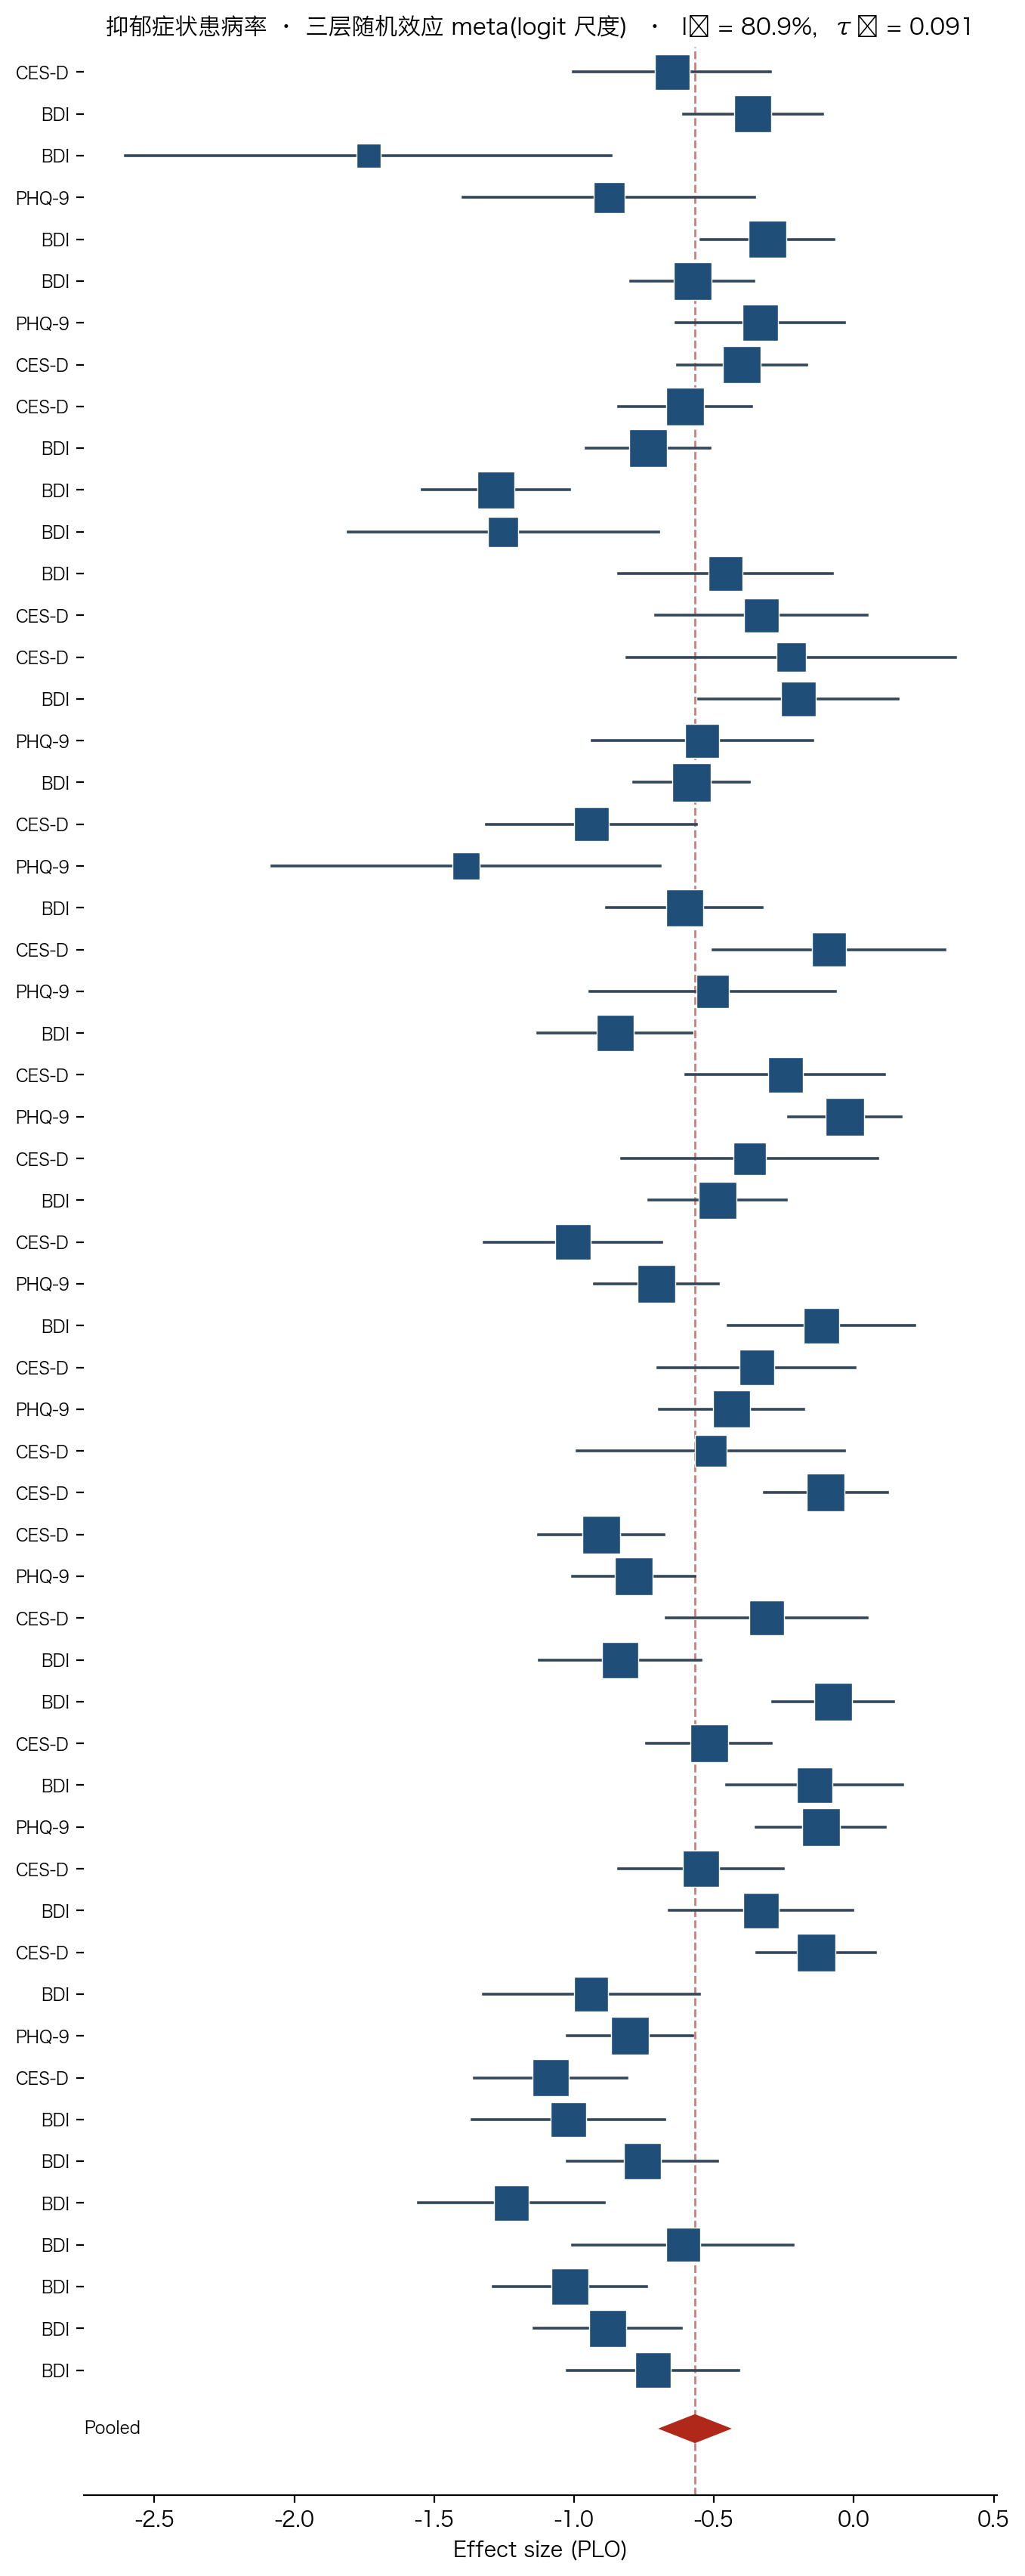

In [15]:
sv.pl.meta_forest(study, out="fig28_forest.png",
                  title="抑郁症状患病率 · 三层随机效应 meta(logit 尺度)")
Image("fig28_forest.png")

In [16]:
sv.tl.backtransform_proportion(study, measure="PLO")
pp = study.diagnostics["pooled_proportion"]
print(f"合并患病率 = {pp['proportion']*100:.1f}%  95% CI [{pp['ci_lb']*100:.1f}%, {pp['ci_ub']*100:.1f}%]")
print(f"(由 logit {mv['estimate']:.3f} 回变换;这是可直接写进摘要的数)")

合并患病率 = 36.2%  95% CI [33.4%, 39.0%]
(由 logit -0.568 回变换;这是可直接写进摘要的数)


## 13. End-to-End Synthesis (Closure): GRADE Evidence Certainty

**Problem addressed**: once all evidence is assembled, readers want one sentence—**how trustworthy is this conclusion?** GRADE codifies it into four tiers: High / Moderate / Low / Very Low. Observational studies (to which prevalence reviews belong) **start at Low**, then **downgrade** via five domains or **upgrade** via large effects.

**Key premise**: GRADE is **arithmetic + suggestions**, not reviewer decree. `grade` automatically **suggests** two domains from evidence signals: inconsistency (from prior I²) and publication bias (from Egger p); the rest (risk of bias, indirectness, imprecision) are **reviewer-entered**. This neatly bundles all prior outputs into one judgment.

**Steps**: set `design='observational'`, reviewers enter `risk_of_bias`/`imprecision` flags, the function reads `diagnostics['heterogeneity']` and `diagnostics['egger']` to suggest, and outputs final certainty.

In [17]:
sv.gov.grade(
    study,
    design="observational",          # 患病率综述 → 起点 Low
    risk_of_bias=1,                  # 评审判断:部分研究偏倚风险高 → 降 1
    indirectness=0,
    imprecision=0,
    # inconsistency / publication_bias 留空 → 由 I²、Egger 自动建议
)
gr = study.governance["grade"]
print(f"起点({gr['start']}) → 最终证据确定性:{gr['certainty']}(level {gr['level']}/4)")
print(f"降级:{gr['downgrades']}")
print(f"升级:{gr['upgrades']}")
print(f"自动建议 · 不一致性(来自 I²)= {gr['suggested_inconsistency']}"
      f"   发表偏倚(来自 Egger)= {gr['suggested_publication_bias']}")
print(f"说明:{gr['note']}")

起点(Low) → 最终证据确定性:Very low(level 1/4)
降级:{'risk_of_bias': 1, 'indirectness': 0, 'imprecision': 0, 'inconsistency': 2, 'publication_bias': 0}
升级:{'large_effect': 0, 'dose_response': 0, 'confounding_toward_null': 0}
自动建议 · 不一致性(来自 I²)= 2   发表偏倚(来自 Egger)= 0
说明:domain suggestions are from I²/Egger; final GRADE call is reviewer judgement


## Summary: A Verifiable Evidence Chain from Record Counting to GRADE

This notebook embeds "governance" into meta-analysis and walks through an **end-to-end** prevalence systematic review—every step lands on the same `StudyState`, every number traces back to which `sv.*` function and which data it came from:

```
Governance layer (must be documented before reporting significance):
  sv.gov.prisma_flow ─────▶ record counting + arithmetic consistency (1284→28, consistent)
  sv.pl.prisma_diagram ───▶ PRISMA flow diagram
  sv.gov.prisma_checklist ▶ 27-item reporting completeness
  sv.gov.screen_agreement ▶ κ low but AC1/PABAK high (unmasking prevalence paradox)
  sv.gov.risk_of_bias / sv.pl.rob_traffic_light ▶ per-study × domain bias traffic light

Synthesis layer (ECR-style three-level prevalence meta):
  sv.pp.es_proportion(PLO) ──▶ logit-prevalence effect sizes (yi, vi)
  sv.tl.vcalc(rho=0.6) ──────▶ block-diagonal sampling covariance V
  sv.tl.rma_mv ─────────────▶ three-level pooling + σ²₂/σ²₃ components
  sv.tl.meta_heterogeneity / ma_i2_multilevel ▶ overall I² + stratified I²
  sv.tl.metareg / metareg_fdr ▶ moderator explanation + FDR correction
  sv.tl.egger_test ─────────▶ publication bias (feeds GRADE)
  sv.pl.meta_forest ────────▶ forest plot
  sv.tl.backtransform_proportion ▶ back-transform to readable prevalence
  sv.gov.grade ─────────────▶ evidence certainty (I²/Egger auto-suggest + reviewer input)
```

**Key point**: a systematic review's credibility depends not just on the pooled number—it rests on a complete chain: **retrieval transparency (PRISMA), screening reliability (κ/AC1), study credibility (RoB), honest heterogeneity (stratified I²), auditable bias (Egger), tiered strength (GRADE)**. The governance layer does accounting and arithmetic; suggestions go to reviewers for confirmation—the whole chain leaves a trace and respects authority. This is **verifiability**. Thus the meta-analysis series (22–28) closes: from basic two-level pooling, all the way to end-to-end replication with governance and three-level structure.